## PRESENTACION PROYECTO H2


Integrantes:
- Danner Leonel Ruiz Condori
- Sebastian Martin Gomez Trincado
- Marcelo Velarde Ali
- Jhoel Julio Quispe Quispe
- Cesar Augusto Perales Lopez

### 2. **Pasos clave del EDA**
#### a) **Revisión inicial de los datos**
- Dimensiones del dataset (número de filas y columnas).
- Tipos de variables: numéricas, categóricas, fechas, texto.
- Ejemplo: dataset de ventas → columnas como “precio”, “categoría”, “fecha”.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np

In [6]:
## Cargado de datos

df_bf = pd.read_csv("healthcare_dataset.csv")



In [7]:
df_bf

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55495,eLIZABeTH jaCkSOn,42,Female,O+,Asthma,2020-08-16,Joshua Jarvis,Jones-Thompson,Blue Cross,2650.714952,417,Elective,2020-09-15,Penicillin,Abnormal
55496,KYle pEREz,61,Female,AB-,Obesity,2020-01-23,Taylor Sullivan,Tucker-Moyer,Cigna,31457.797307,316,Elective,2020-02-01,Aspirin,Normal
55497,HEATher WaNG,38,Female,B+,Hypertension,2020-07-13,Joe Jacobs DVM,"and Mahoney Johnson Vasquez,",UnitedHealthcare,27620.764717,347,Urgent,2020-08-10,Ibuprofen,Abnormal
55498,JENniFER JOneS,43,Male,O-,Arthritis,2019-05-25,Kimberly Curry,"Jackson Todd and Castro,",Medicare,32451.092358,321,Elective,2019-05-31,Ibuprofen,Abnormal


In [12]:
# dimensiones
df_bf.shape

(55500, 15)

In [13]:
#tipos de variables 
df_bf.dtypes

Name                      str
Age                     int64
Gender                    str
Blood Type                str
Medical Condition         str
Date of Admission         str
Doctor                    str
Hospital                  str
Insurance Provider        str
Billing Amount        float64
Room Number             int64
Admission Type            str
Discharge Date            str
Medication                str
Test Results              str
dtype: object

#### b) **Calidad de los datos**
- Valores faltantes (missing values).
- Duplicados.
- Errores de formato (ej. fechas mal registradas).
- Ejemplo: registros de clientes con edad = 0 o >120.

In [15]:
# valores faltantes
df_bf.isnull().sum()

Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64

In [16]:
#valores duplicados
df_bf.duplicated().sum

<bound method Series.sum of 0        False
1        False
2        False
3        False
4        False
         ...  
55495    False
55496    False
55497    False
55498    False
55499    False
Length: 55500, dtype: bool>

#errores de formato
no contamos con errores de formato

#### c) **Distribución de variables**
- Histogramas y frecuencias.
- Medidas de tendencia central (media, mediana, moda).
- Medidas de dispersión (varianza, desviación estándar).
- Ejemplo: distribución de ingresos de clientes para detectar sesgos.

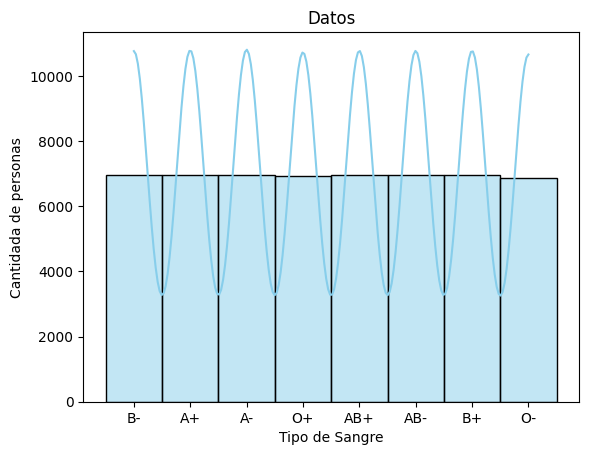

In [18]:
#histograma

sns.histplot(df_bf["Blood Type"], bins=10, kde=True, color="skyblue")
plt.title("Datos")
plt.xlabel("Tipo de Sangre")
plt.ylabel("Cantidada de personas")
plt.show()

## medidas de tendencia central


In [19]:
#media
media_edad = df_bf ["Age"].mean()
print(f"La media es: {media_edad}")

La media es: 51.53945945945946


In [20]:
#mediana
mediana_edad = df_bf["Age"].median()
print(f"La mediana es: {mediana_edad}")

La mediana es: 52.0


In [21]:
#moda
moda_sangre = df_bf["Blood Type"].mode()[0]
print(f"La moda es: {moda_sangre}")

La moda es: A-


# medidas de dispersion

In [22]:
#desviacion estandar de la edad
desviacion = df_bf["Age"].std()
print(f"Desviacion Estandar:{desviacion}")

Desviacion Estandar:19.602453808514348


In [23]:
#varianza
varianza = df_bf["Age"].var()
print(f"Varianza: {varianza}")


Varianza: 384.2561953149387


#### d) **Detección de outliers**
- Boxplots para identificar valores extremos.
- Ejemplo: ventas de un día que superan 10 veces el promedio.

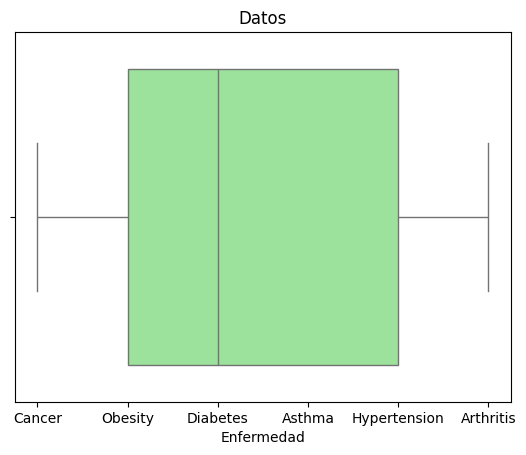

In [25]:
# boxplots
sns.boxplot(x=df_bf["Medical Condition"], color="lightgreen")
plt.title("Datos")
plt.xlabel("Enfermedad")
plt.show()

#### e) **Relaciones entre variables**
- Correlaciones (Pearson, Spearman).
- Tablas cruzadas para variables categóricas.
- Ejemplo: relación entre nivel educativo y salario.

In [29]:
#correlacion
df_bf.corr(method='pearson', numeric_only=True)

,Age,Billing Amount,Room Number
Age,1.000000,-0.003832,-0.000720
Billing Amount,-0.003832,1.000000,-0.002943
Room Number,-0.000720,-0.002943,1.000000


In [28]:
#correlacion
df_bf.corr(method='spearman', numeric_only=True)


,Age,Billing Amount,Room Number
Age,1.000000,-0.003662,-0.000667
Billing Amount,-0.003662,1.000000,-0.002894
Room Number,-0.000667,-0.002894,1.000000


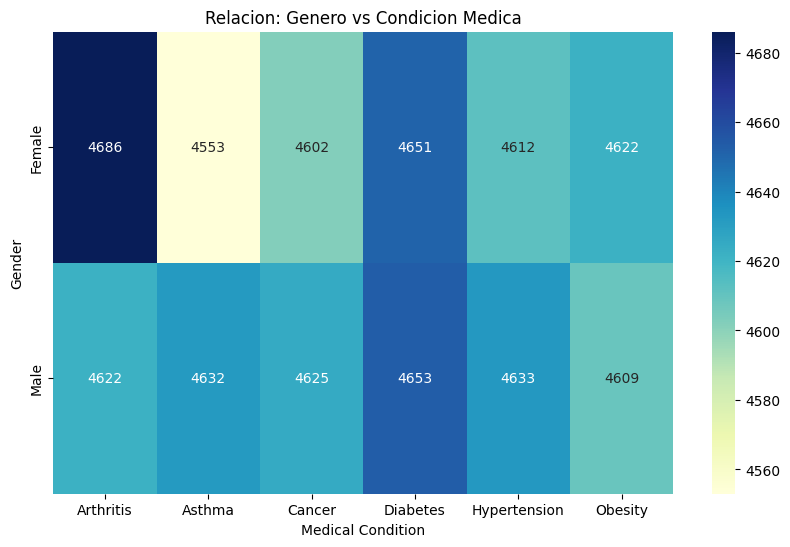

In [31]:
#tablas cruzadas para variables categoricas

tabla = pd.crosstab(df_bf['Gender'],
            df_bf['Medical Condition'])

plt.figure(figsize=(10,6))
sns.heatmap(tabla, annot=True,fmt='d', cmap='YlGnBu')
plt.title('Relacion: Genero vs Condicion Medica')
plt.show()